In [185]:
import pandas as pd
import seaborn as sns

<Axes: xlabel='Year', ylabel='GDP'>

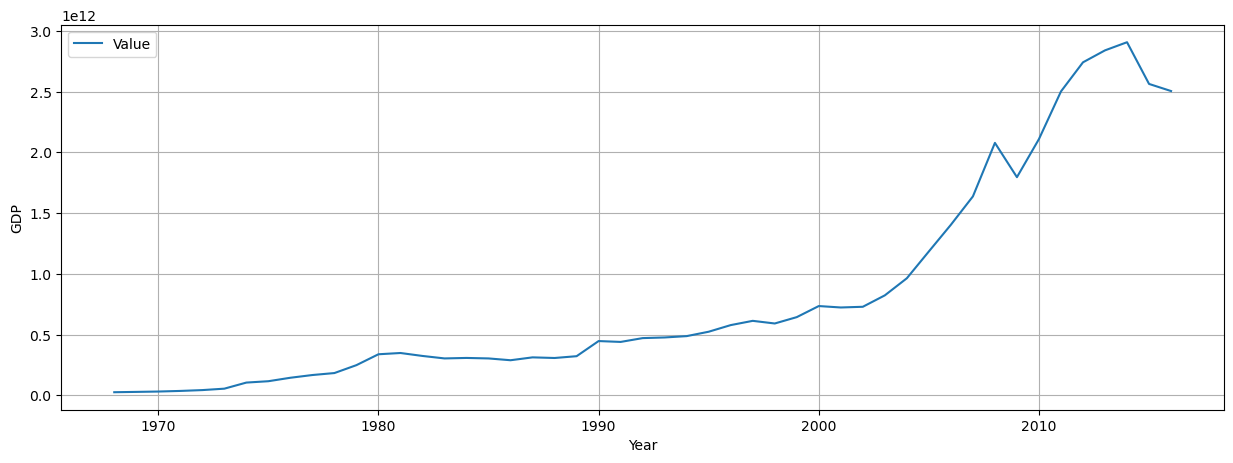

In [187]:
df=pd.read_csv('gdp.csv')
df.head(10)
dfp=df[df['Country Name']=='Arab World']
#here I am having the rows which face true when used in the condition 
dfp.plot(kind='line',x='Year',y='Value',figsize=(15,5),grid=True,ylabel='GDP')

In [189]:
# In this section I'll try to create a column with the percentage growth of every county concerning the year 
df.head()

,Country Name,Country Code,Year,Value
0,Arab World,ARB,1968,2.576068e+10
1,Arab World,ARB,1969,2.843420e+10
2,Arab World,ARB,1970,3.138550e+10
3,Arab World,ARB,1971,3.642691e+10
4,Arab World,ARB,1972,4.331606e+10


In [191]:
# This whole code is for a single country 
df=df[df['Country Name']=='India']
df_p=df.values
lst=[10.3]
for i in range(1,len(df_p)):
    cur=df_p[i][3]
    prv=df_p[i-1][3]
    lst.append(round(((cur-prv)/prv)*100,2))

df.assign(GDP=lst)
df.head()

,Country Name,Country Code,Year,Value
6074,India,IND,1960,3.653593e+10
6075,India,IND,1961,3.870910e+10
6076,India,IND,1962,4.159907e+10
6077,India,IND,1963,4.777600e+10
6078,India,IND,1964,5.572687e+10


In [323]:
# Now I will make the code work for every country 
df=pd.read_csv('gdp.csv')
final_lst=[]
for country_name in df['Country Name'].unique():
    df_p=df[df['Country Name']==country_name]
    lst=[0]
    
    data=df_p.values
    for i in range(1,len(data)):
        cur=data[i][3]
        prv=data[i-1][3]
        lst.append(round(((cur-prv)/prv)*100,2))

     
    df_p=df_p.assign(GDP=lst)
    final_lst.append(df_p)
    
df=pd.concat(final_lst,axis=0)



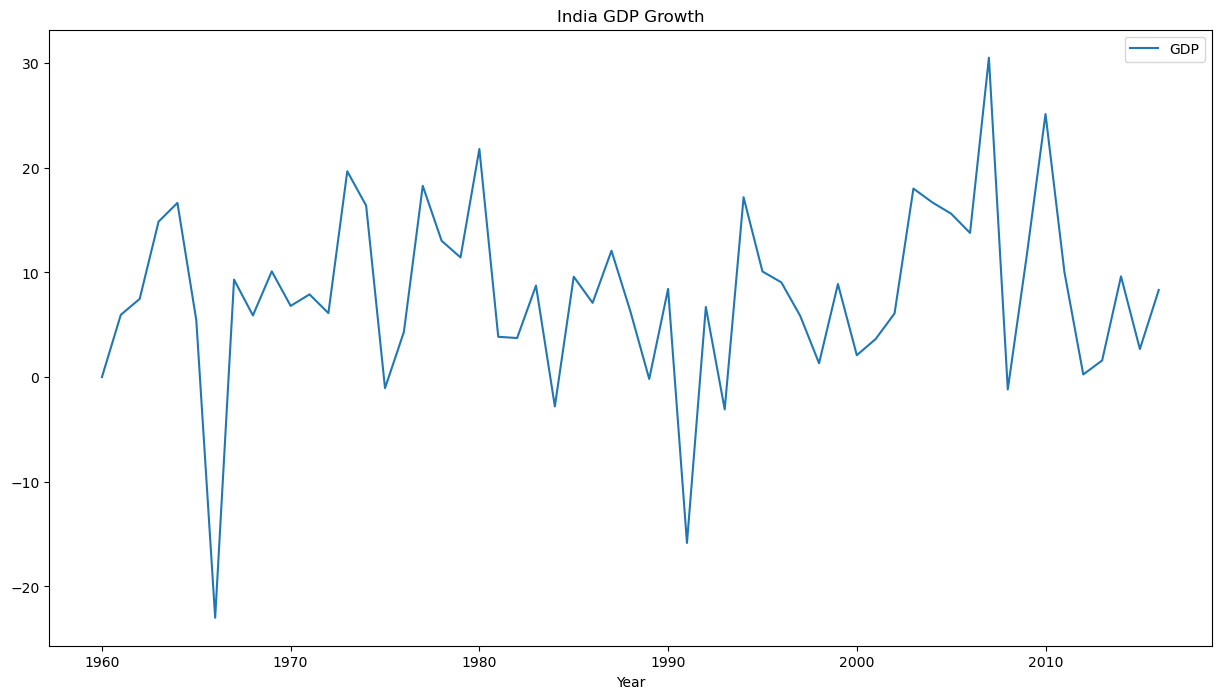

In [195]:
df_p=df[df['Country Name']=='India'].plot(kind='line',y='GDP',x='Year',title='India GDP Growth',figsize=(15,8))


In [197]:
# Here I have found the average GDP of the countries 
df.groupby('Country Name').mean('GDP')

,Year,Value,GDP
Country Name,,,
Afghanistan,1986.5,6.226405e+09,11.204737
Albania,2000.0,6.011364e+09,8.232121
Algeria,1988.0,6.147467e+10,8.415614
American Samoa,2009.0,5.805333e+08,1.937333
Andorra,1993.0,1.468489e+09,8.817660
...,...,...,...
West Bank and Gaza,2005.0,6.648426e+09,7.273913
World,1988.0,2.609594e+13,7.454386
"Yemen, Rep.",2003.0,1.746357e+10,7.137037


##Offline Virtualization##

In [199]:
import plotly.express as px
import plotly.offline as pyo


In [201]:
# First we will try to generate and save the graph of world gdp 
df_p=df[df['Country Name']=='World']
fig=px.line(df_p,x='Year',y='Value',title="World GDP",color= 'Country Name')
pyo.plot(fig,filename='World GDP.html')

'World GDP.html'

In [203]:
# now I will try to create a graph of the world's GDP growth 
df_p=df[df['Country Name']=='India']
fig=px.line(df_p,x='Year',y='Value',title="India GDP",color= 'Country Name',range_y=(0,80000000000000))
pyo.plot(fig,filename='India GDP.html',auto_open=False)

'India GDP.html'

In [205]:
# After this, we will try to make an automated system to make a graph for every country and save them in a file 
import os 
os.mkdir('Every country gpd graph')

In [211]:
for i in df['Country Name'].unique():
    df_p=df[df['Country Name']==i]
    fig=px.line(df_p,x='Year',y='Value',title= i+'GDP Analysis')
    pyo.plot(fig,filename='Every country gpd graph/'+i+'GDP Analysis.html',auto_open=False)

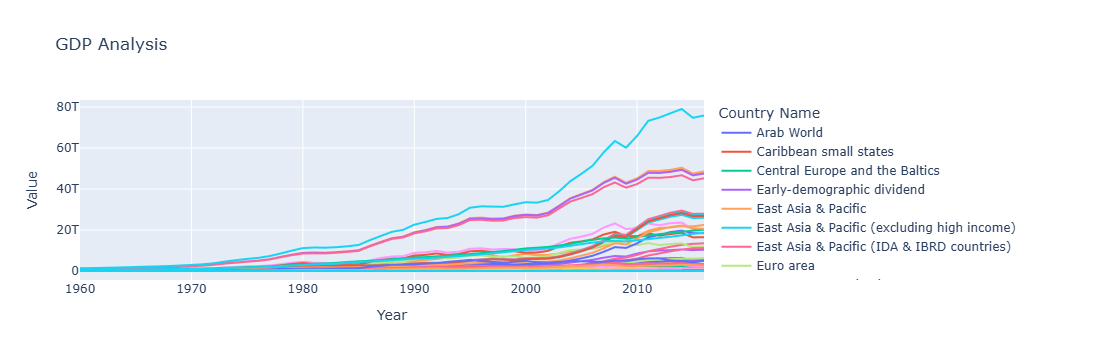

In [291]:
#Creating a single graph which contain every  
fig=px.line(df,x='Year',y='Value',title='GDP Analysis',color='Country Name')
fig

In [289]:
#Now trying to compare the GDP of different countries, 
c1=df[df['Country Name']=='India']
c2=df[df['Country Name']=='China']
df_p=pd.concat([c1,c2],axis=0)
fig=px.line(df_p,x='Year',y='Value',title='Comparition B/W India China GDP',color='Country Name')
pyo.plot(fig)

'temp-plot.html'

In [309]:
#Creating a function which can display the multiple comparisons 
lst=['IND','ITA','USA','CHN']
ds=[]
def compare(lst,ope):
    for i in lst:
        df_p=df[df['Country Code']==i]
        ds.append(df_p)
    df_pr=pd.concat(ds,axis=0)
    fig=px.line(df_pr,x='Year',y='Value',title='Comparision graph',color='Country Name')
    pyo.plot(fig,filename='Compare'+i+'.html',auto_open=ope)
    

In [311]:
compare(lst,False)

In [327]:
##Now creating a growth comparison graph of thoes country who dont have mising value 
# first i will find the country which dont have the mising years 
ds=[]
for i in df['Country Name'].unique():
    df_p=df[df['Country Name']==i]
    if len(df_p)==57:
        ds.append(df_p)
df_pr=pd.concat(ds,axis=0)        
    
fig=px.line(df_pr,x='Year',y='GDP',title='GDP Analysis',color='Country Name')
pyo.plot(fig,filename='GDP growth Analysis.html',auto_open=True)

'GDP growth Analysis.html'